#Exercise - 1

1. Read and Display the image

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

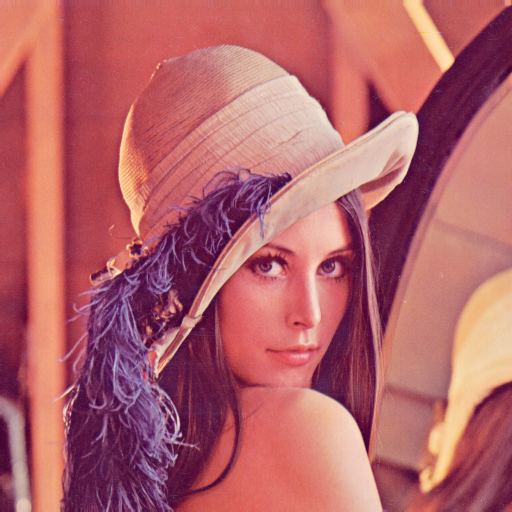

In [2]:
from PIL import Image
#Reading the image using Pillow Lib
image = Image . open ("lena.png")
#Displaying the image
display( image )

2. Display only the top left corner of 100x100 pixels.

In [12]:
# # Define the cropping box (left , upper , right , lower )
# left = 100
# upper = 50
# right = 200
# lower = 150

# # Crop the image
# cropped_image = image . crop (( left , upper , right ,lower ) )
# # Display the cropped image
# display ( cropped_image )

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

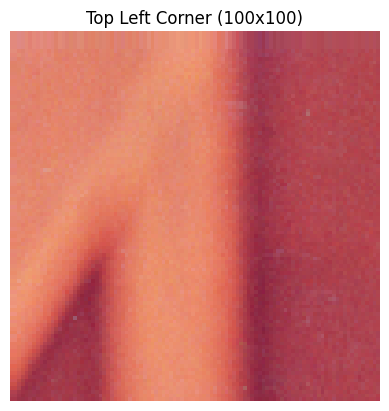

In [11]:
img_array = mpimg.imread("lena.png")

top_left_corner = img_array[0:100, 0:100, :]

plt.imshow(top_left_corner)
plt.title("Top Left Corner (100x100)")
plt.axis('off')


3. Show the three color channels (R, G, B)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

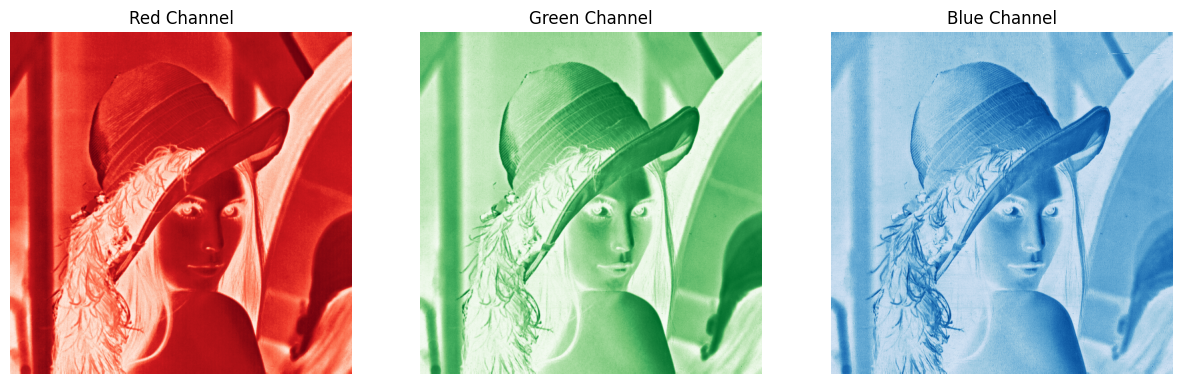

In [18]:
red_channel = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Red Channel
axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title("Red Channel")
axes[0].axis('off')

# Green Channel
axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title("Green Channel")
axes[1].axis('off')

# Blue Channel
axes[2].imshow(blue_channel, cmap='Blues')
axes[2].set_title("Blue Channel")
axes[2].axis('off')

4. Modify Top $100 \times 100$ Pixels to 210

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

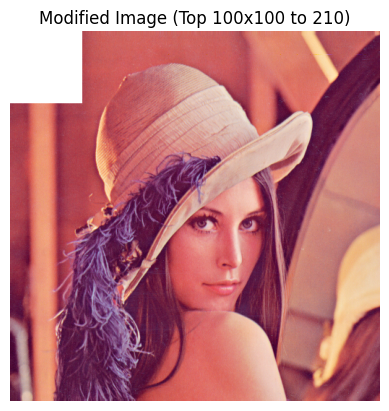

In [21]:
modified_img = img_array.copy()
modified_img[:100, :100, :] = 210 # Assign light gray value

plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 to 210)")
plt.axis('off')


#Exercise -2

1. Load and display a grayscale image.

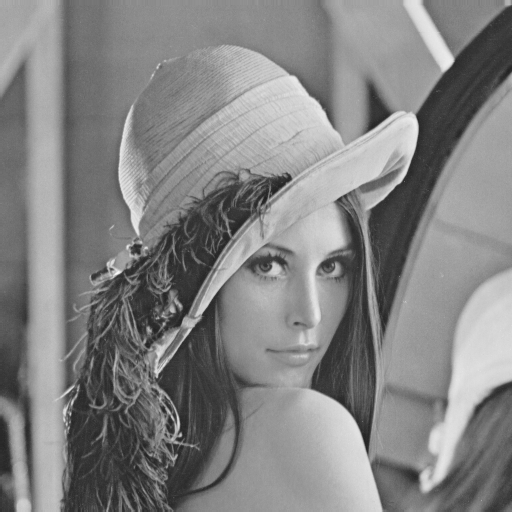

In [25]:
# img_gray = mpimg.imread("lena_grey.png")
image_gray = Image . open ("lena_grey.png")
display(image_gray)

2. Extract and display the middle section of the image (150 pixels)

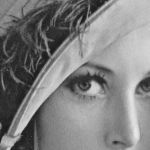

In [29]:
image_gray = Image.open("lena.png").convert('L')

gray_array = np.array(image_gray)

h, w = gray_array.shape
mid_h, mid_w = h // 2, w // 2

#Slicing
middle_crop = gray_array[mid_h-75:mid_h+75, mid_w-75:mid_w+75]

#Displaying
display(Image.fromarray(middle_crop))

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

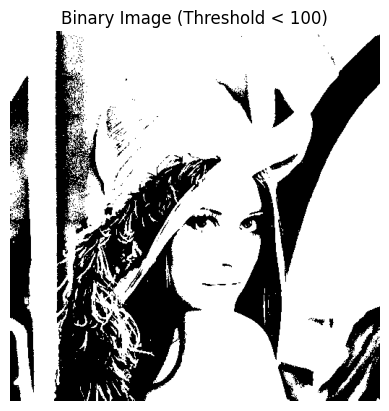

In [32]:
binary_array = np.where(gray_array < 100, 0, 255).astype(np.uint8)

plt.imshow(binary_array, cmap='gray')
plt.title("Binary Image (Threshold < 100)")
plt.axis('off')

4. Rotate the image 90 degrees clockwise and display the result.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

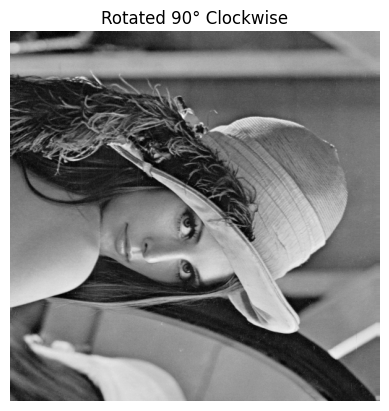

In [33]:
rotated_array = np.rot90(gray_array, k=-1)

# Display using matplotlib
plt.imshow(rotated_array, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis('off')

5. Convert the grayscale image to an RGB image.

Original shape: (512, 512)
New RGB shape: (512, 512, 3)


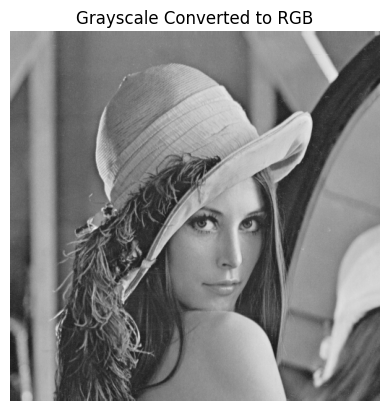

In [36]:
rgb_from_gray = np.stack([gray_array, gray_array, gray_array], axis=-1)

# Display the converted RGB image
plt.imshow(rgb_from_gray)
plt.title("Grayscale Converted to RGB")
plt.axis('off')

#Verifying the result
print(f"Original shape: {gray_array.shape}")
print(f"New RGB shape: {rgb_from_gray.shape}")

#Exercise - 3

1. Load and Prepare Data

In [38]:
image_gray = Image.open("lena.png").convert('L')
gray_array = np.array(image_gray, dtype=float)

# • Center the dataset (Standardize)
# Calculate mean for each column
mean_val = np.mean(gray_array, axis=0)
standardized_data = gray_array - mean_val

# • Calculate the Covariance Matrix
# rowvar=False because our features (pixels) are in columns
covariance_matrix = np.cov(standardized_data, rowvar=False)

print("Covariance Matrix Shape:", covariance_matrix.shape)

Covariance Matrix Shape: (512, 512)


2. Eigen Decomposition and Identifying Principal Components

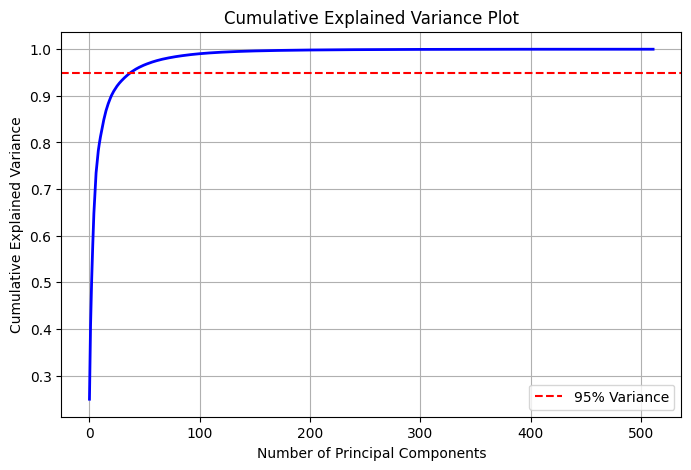

In [42]:
# • Compute Eigenvalues and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

# • Sort eigenvalues in descending order
# linalg.eigh returns them in ascending order, so we reverse them
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# • Identify Principal Components with Cumulative Sum Plot
# Explained variance ratio shows how much info each component holds
explained_variance_ratio = sorted_eigenvalue / np.sum(sorted_eigenvalue)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, color='blue', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.title("Cumulative Explained Variance Plot")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)


3. Reconstruction and Experiment

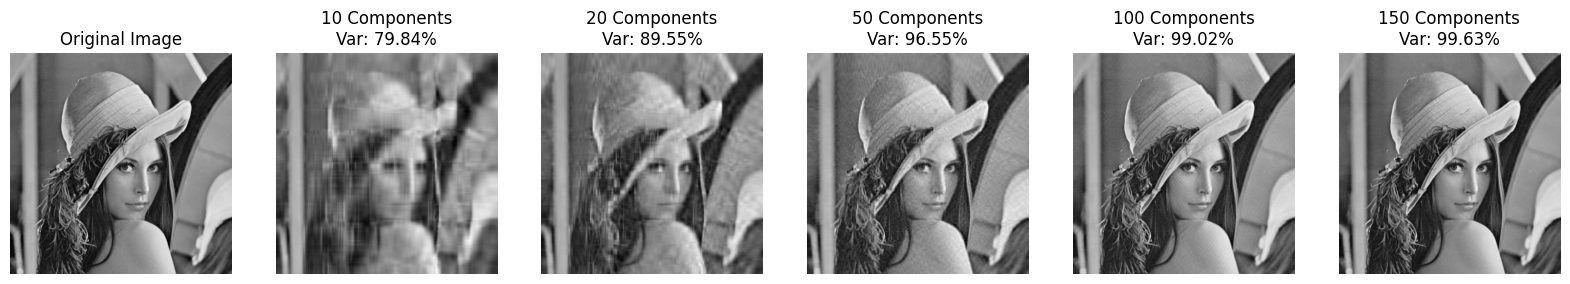

In [48]:
def pca_reconstruct(data, vectors, mean, k):
    # Select top k eigenvectors
    selected_vectors = vectors[:, :k]

    # 1. Compression (Projection to lower dimension)
    # Original (512x512) dot Selected_Vectors (512x k) -> Compressed (512x k)
    compressed_data = np.dot(data, selected_vectors)

    # 2. Reconstruction (Back to original dimension)
    # Compressed (512x k) dot Transposed_Vectors (k x512) -> Reconstructed (512x512)
    reconstructed_data = np.dot(compressed_data, selected_vectors.T) + mean
    return reconstructed_data

# • Experiments: Compare 4 different combinations of k
components_to_test = [10, 20, 50, 100, 150]
plt.figure(figsize=(20, 10))

# Display Original for comparison
plt.subplot(1, 6, 1)
plt.imshow(gray_array, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Display Reconstructed versions
for i, k in enumerate(components_to_test):
    reconstructed = pca_reconstruct(standardized_data, sorted_eigenvectors, mean_val, k)

    plt.subplot(1, 6, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"{k} Components\nVar: {cumulative_variance[k-1]:.2%}")
    plt.axis('off')

# plt.tight_layout()